Using device: cpu
Generating Disordered phase data 0/300, elapsed 2.17s
Generating Disordered phase data 10/300, elapsed 2.25s
Generating Disordered phase data 20/300, elapsed 2.31s
Generating Disordered phase data 30/300, elapsed 2.38s
Generating Disordered phase data 40/300, elapsed 2.45s
Generating Disordered phase data 50/300, elapsed 2.50s
Generating Disordered phase data 60/300, elapsed 2.57s
Generating Disordered phase data 70/300, elapsed 2.63s
Generating Disordered phase data 80/300, elapsed 2.70s
Generating Disordered phase data 90/300, elapsed 2.76s
Generating Disordered phase data 100/300, elapsed 2.82s
Generating Disordered phase data 110/300, elapsed 2.89s
Generating Disordered phase data 120/300, elapsed 2.98s
Generating Disordered phase data 130/300, elapsed 3.04s
Generating Disordered phase data 140/300, elapsed 3.09s
Generating Disordered phase data 150/300, elapsed 3.15s
Generating Disordered phase data 160/300, elapsed 3.23s
Generating Disordered phase data 170/300,

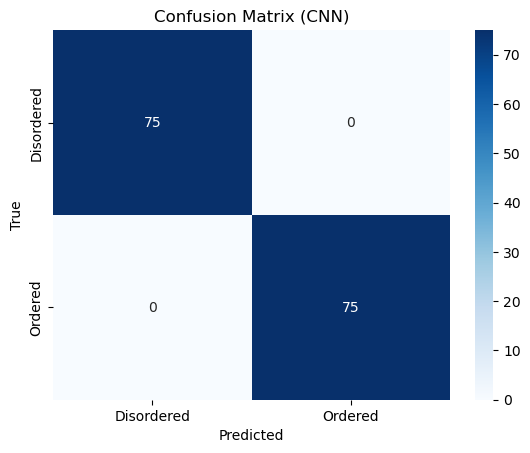

Epoch 1, Train Loss: 0.7203, Val Loss: 0.6546
Epoch 2, Train Loss: 0.6460, Val Loss: 0.6053
Epoch 3, Train Loss: 0.5758, Val Loss: 0.5586
Epoch 4, Train Loss: 0.5095, Val Loss: 0.5027
Epoch 5, Train Loss: 0.4159, Val Loss: 0.4661
Epoch 6, Train Loss: 0.3671, Val Loss: 0.4718
Epoch 7, Train Loss: 0.2903, Val Loss: 0.4890
Epoch 8, Train Loss: 0.2594, Val Loss: 0.4122
Epoch 9, Train Loss: 0.2135, Val Loss: 0.4222
Epoch 10, Train Loss: 0.1904, Val Loss: 0.4772
Epoch 11, Train Loss: 0.1290, Val Loss: 0.4502
Epoch 12, Train Loss: 0.2142, Val Loss: 0.3916
Epoch 13, Train Loss: 0.1773, Val Loss: 0.5343
Epoch 14, Train Loss: 0.2560, Val Loss: 0.4974
Epoch 15, Train Loss: 0.1307, Val Loss: 0.4998
Epoch 16, Train Loss: 0.1184, Val Loss: 0.3995
Epoch 17, Train Loss: 0.1412, Val Loss: 0.4472
Early stopping
Test Accuracy (PCA + NN): 77.33%


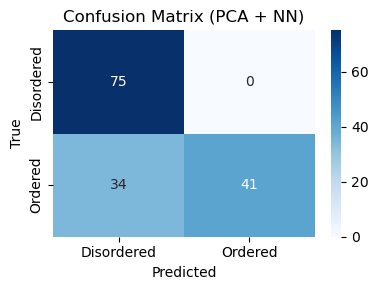

Fitting 5 folds for each of 42 candidates, totalling 210 fits
SVM best params: {'C': 2, 'gamma': 0.005, 'kernel': 'rbf'}
==>  Optimized SVM test acc: 0.9133333333333333
Opt RF: {'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 1000} Test acc: 0.94
===   PCA Features + Optimal Parameters  ===
SVM  acc: 0.5067
RF   acc: 0.6533
=== Traditional Model Accuracy (Raw vs PCA) ===
SVM  : Raw 0.9133 | PCA 0.5067
RF   : Raw 0.9400 | PCA 0.6533


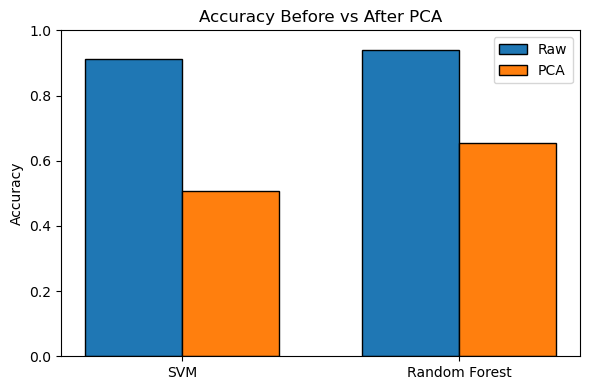

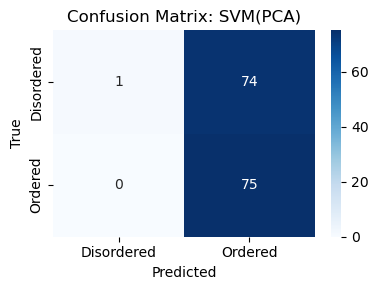

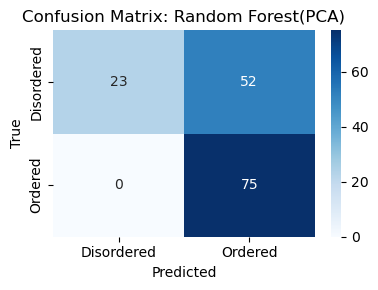

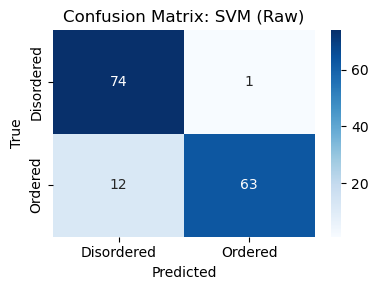

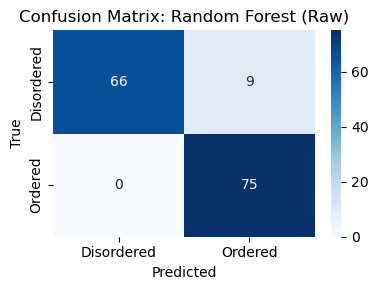

Noise 0.00% -> CNN acc: 1.000, PCA+NN acc: 0.773| SVM 0.913 | RF 0.940
Noise 0.05% -> CNN acc: 1.000, PCA+NN acc: 0.773| SVM 0.913 | RF 0.940
Noise 0.10% -> CNN acc: 1.000, PCA+NN acc: 0.787| SVM 0.900 | RF 0.940
Noise 0.15% -> CNN acc: 1.000, PCA+NN acc: 0.773| SVM 0.900 | RF 0.940
Noise 0.20% -> CNN acc: 1.000, PCA+NN acc: 0.773| SVM 0.900 | RF 0.940
Noise 0.25% -> CNN acc: 1.000, PCA+NN acc: 0.773| SVM 0.887 | RF 0.933
Noise 0.30% -> CNN acc: 1.000, PCA+NN acc: 0.753| SVM 0.867 | RF 0.933
Noise 0.35% -> CNN acc: 1.000, PCA+NN acc: 0.767| SVM 0.867 | RF 0.933
Noise 0.40% -> CNN acc: 1.000, PCA+NN acc: 0.773| SVM 0.860 | RF 0.933
Noise 0.45% -> CNN acc: 1.000, PCA+NN acc: 0.773| SVM 0.860 | RF 0.940
Noise 0.50% -> CNN acc: 1.000, PCA+NN acc: 0.767| SVM 0.860 | RF 0.933
Noise 0.55% -> CNN acc: 1.000, PCA+NN acc: 0.753| SVM 0.827 | RF 0.933
Noise 0.60% -> CNN acc: 1.000, PCA+NN acc: 0.760| SVM 0.833 | RF 0.947
Noise 0.65% -> CNN acc: 1.000, PCA+NN acc: 0.767| SVM 0.833 | RF 0.940
Noise 

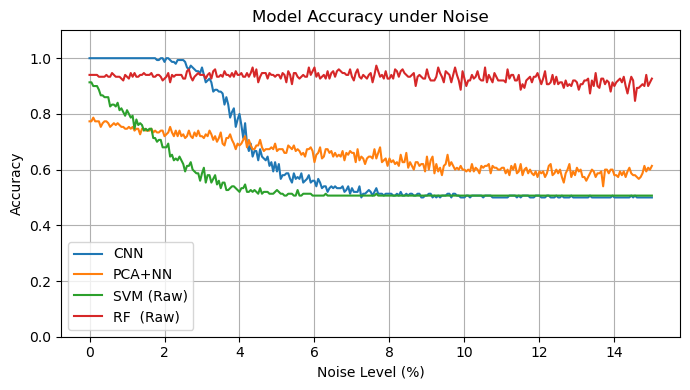

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import os
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import multiprocessing as mp   # <— Added



def monte_carlo_ising(size=32, temp=2.0, steps=10000):
    spins = np.random.choice([-1, 1], size=(size, size))
    for _ in range(steps):
        i, j = np.random.randint(0, size, 2)
        neighbors = spins[(i+1)%size, j] + spins[(i-1)%size, j] + \
                    spins[i, (j+1)%size] + spins[i, (j-1)%size]
        energy_diff = 2 * spins[i, j] * neighbors
        if energy_diff <= 0 or (np.random.random() < np.exp(-energy_diff/temp)):
            spins[i, j] *= -1
    return spins

def _gen_single_sample(args):
    """Pool worker: Only generates one Ising configuration."""
    temp = args[0]
    return monte_carlo_ising(temp=temp)

def generate_data(n_samples, temp, label, description,
                  n_workers: int | None = None):     # ==== NEW ====
    """
    n_workers = None or 1  : Use original single-process logic;
    n_workers >=2          : Enable multiprocessing.Pool for parallel processing.
    """
    start_time = time.time()

    # ---------- Parallel path ----------
    if n_workers and n_workers > 1:
        results = []
        with mp.Pool(processes=n_workers) as pool:
            # imap_unordered produces and consumes simultaneously, saving memory
            for i, spins in enumerate(pool.imap_unordered(
                    _gen_single_sample, [(temp,)] * n_samples)):
                results.append(spins)
                if i % 10 == 0:
                    elapsed = time.time() - start_time
                    print(f"Generating {description} data "
                          f"{i}/{n_samples}, elapsed {elapsed:.2f}s")
        X_data = np.array(results)
    # ---------- Single process path ----------
    else:
        X_data = []
        for i in range(n_samples):
            if i % 10 == 0:
                elapsed = time.time() - start_time
                print(f"Generating {description} data "
                      f"{i}/{n_samples}, elapsed {elapsed:.2f}s")
            X_data.append(monte_carlo_ising(temp=temp))
        X_data = np.array(X_data)

    print(f"{description} data generation completed, "
          f"Total time: {time.time() - start_time:.2f} seconds")
    return X_data, np.full(n_samples, label)

def main():
    n_samples = 300
    T_critical = 2.27
    X_disordered, y_disordered = generate_data(n_samples, 3, 0,
                                               "Disordered phase",
                                               n_workers=mp.cpu_count())
    X_ordered, y_ordered = generate_data(n_samples, 1.5, 1,
                                         "Ordered phase",
                                         n_workers=mp.cpu_count())
    X = np.concatenate([X_disordered, X_ordered])
    y = np.concatenate([y_disordered, y_ordered])
    X = (X + 1) / 2  # Normalize to 0/1
    X = X[:, np.newaxis, :, :]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    class ProjectCNN(nn.Module):
        def __init__(self):
            super(ProjectCNN, self).__init__()
            self.conv1 = nn.Conv2d(1, 64, kernel_size=2)
            self.pool = nn.MaxPool2d(2)
            self.fc1 = nn.Linear(64 * 15 * 15, 64)
            self.dropout = nn.Dropout(0.5)
            self.fc2 = nn.Linear(64, 2)

        def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))
            x = x.view(-1, 64 * 15 * 15)
            x = F.relu(self.fc1(x))
            x = self.dropout(x)
            x = self.fc2(x)
            return x

    model = ProjectCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    num_epochs = 10
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = 100 * correct / total
    print(f"Test Accuracy (CNN): {accuracy:.2f}%")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Disordered", "Ordered"], yticklabels=["Disordered", "Ordered"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (CNN)")
    plt.show()

    # Ready for PCA + NN
    X_train_flat = X_train.view(X_train.size(0), -1).numpy()
    X_test_flat = X_test.view(X_test.size(0), -1).numpy()

    n_components = 100
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_flat)
    X_test_pca = pca.transform(X_test_flat)

    X_train_pca_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
    X_test_pca_tensor = torch.tensor(X_test_pca, dtype=torch.float32)

    train_loader_pca = DataLoader(TensorDataset(X_train_pca_tensor, y_train), batch_size=16, shuffle=True)
    test_loader_pca = DataLoader(TensorDataset(X_test_pca_tensor, y_test), batch_size=16, shuffle=False)

    class ImprovedNN(nn.Module):
        def __init__(self, input_dim=n_components, dropout_rate=0.3):
            super(ImprovedNN, self).__init__()
            self.fc1 = nn.Linear(input_dim, 256)
            self.bn1 = nn.BatchNorm1d(256)
            self.fc2 = nn.Linear(256, 128)
            self.bn2 = nn.BatchNorm1d(128)
            self.fc3 = nn.Linear(128, 64)
            self.bn3 = nn.BatchNorm1d(64)
            self.fc4 = nn.Linear(64, 2)
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, x):
            x = F.relu(self.bn1(self.fc1(x)))
            x = self.dropout(x)
            x = F.relu(self.bn2(self.fc2(x)))
            x = self.dropout(x)
            x = F.relu(self.bn3(self.fc3(x)))
            x = self.dropout(x)
            return self.fc4(x)

    model_pca = ImprovedNN().to(device)
    optimizer_pca = optim.Adam(model_pca.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_pca, 'min', patience=3)
    best_loss = float('inf')
    patience = 5
    patience_counter = 0

    for epoch in range(30):
        model_pca.train()
        running_loss = 0.0
        for inputs, labels in train_loader_pca:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_pca.zero_grad()
            outputs = model_pca(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_pca.step()
            running_loss += loss.item()

        val_loss = 0.0
        model_pca.eval()
        with torch.no_grad():
            for inputs, labels in test_loader_pca:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model_pca(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(test_loader_pca)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}, Train Loss: {running_loss/len(train_loader_pca):.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            torch.save(model_pca.state_dict(), 'best_model_pca.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping")
                break

    # Evaluation on PCA+NN
    model_pca.eval()
    all_preds_pca = []
    all_labels_pca = []
    with torch.no_grad():
        for inputs, labels in test_loader_pca:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_pca(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds_pca.extend(predicted.cpu().numpy())
            all_labels_pca.extend(labels.cpu().numpy())
    accuracy_pca = accuracy_score(all_labels_pca, all_preds_pca)
    print(f"Test Accuracy (PCA + NN): {accuracy_pca*100:.2f}%")

    cm_pca_nn = confusion_matrix(all_labels_pca, all_preds_pca)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_pca_nn, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Disordered", "Ordered"],
                yticklabels=["Disordered", "Ordered"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (PCA + NN)")
    plt.tight_layout()
    plt.show()  

    # ==== Added: Traditional ML models (SVM/RF) and noise robustness analysis ====


    # Use flattened data for traditional model evaluation
    pca_sklearn = PCA(n_components=0.95)
    X_train_pca_sklearn = pca_sklearn.fit_transform(X_train_flat)
    X_test_pca_sklearn = pca_sklearn.transform(X_test_flat)

    # Initialize models


    # Training

    scaler = StandardScaler().fit(X_train_flat)
    X_train_scaled = scaler.transform(X_train_flat)
    X_test_scaled = scaler.transform(X_test_flat)

    param_svm = {
        "C":      [0.5, 2, 3,6,7,10],
        "gamma":  [0.001,0.004,0.005,0.006,0.007 ,0.01, "scale"],
        "kernel": ["rbf"],
    }
    svm_opt = GridSearchCV(
        SVC(),
        param_grid = param_svm,
        cv = StratifiedKFold(5, shuffle=True, random_state=0),
        scoring = "accuracy",
        n_jobs = -1,
        verbose = 1,
    )
    svm_opt.fit(X_train_scaled, y_train.numpy())
    print("SVM best params:", svm_opt.best_params_
            )
    acc_svm_opt = accuracy_score(y_test.numpy(),
                                svm_opt.predict(X_test_scaled))
    print("==>  Optimized SVM test acc:", acc_svm_opt)

    param_rf = {"n_estimators":[900,1000],
                "max_features":[None],
                "min_samples_split":[2,3],
                "max_depth":[None,15]}
    rf_opt = GridSearchCV(RandomForestClassifier(n_jobs=-1, random_state=0),
                        param_rf, cv=5, scoring="accuracy",
                        n_jobs=-1).fit(X_train_scaled, y_train.numpy())
    print("Opt RF:", rf_opt.best_params_,
        "Test acc:", accuracy_score(y_test.numpy(),
                                    rf_opt.predict(X_test_scaled)))

    # =========== ① Re-train "PCA features" models with optimal parameters ===========
    svm_pca_opt = SVC(**svm_opt.best_params_)
    rf_pca_opt  = RandomForestClassifier(
        n_jobs=-1, random_state=0, **rf_opt.best_params_)

    svm_pca_opt.fit(X_train_pca_sklearn, y_train.numpy())
    rf_pca_opt .fit(X_train_pca_sklearn, y_train.numpy())

    acc_svm_pca_opt = accuracy_score(y_test.numpy(),
                                    svm_pca_opt.predict(X_test_pca_sklearn))
    acc_rf_pca_opt  = accuracy_score(y_test.numpy(),
                                    rf_pca_opt .predict(X_test_pca_sklearn))

    print("===   PCA Features + Optimal Parameters  ===")
    print(f"SVM  acc: {acc_svm_pca_opt:.4f}")
    print(f"RF   acc: {acc_rf_pca_opt :.4f}")
    # ==========================================================
    
    svm_raw = svm_opt
    rf_raw  = rf_opt

    # ---------- 2. Calculate accuracy for raw features ----------
    acc_svm_raw = acc_svm_opt
    acc_rf_raw  = accuracy_score(y_test.numpy(),
                                    rf_opt.predict(X_test_scaled))

    print("=== Traditional Model Accuracy (Raw vs PCA) ===")
    print(f"SVM  : Raw {acc_svm_raw:.4f} | PCA {acc_svm_pca_opt:.4f}")
    print(f"RF   : Raw {acc_rf_raw :.4f} | PCA {acc_rf_pca_opt :.4f}")

    models = ["SVM", "Random Forest"]
    raw_scores  = [acc_svm_raw, acc_rf_raw]
    pca_scores  = [acc_svm_pca_opt, acc_rf_pca_opt]

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(6,4))
    plt.bar(x - width/2, raw_scores, width, label="Raw",  edgecolor="black")
    plt.bar(x + width/2, pca_scores, width, label="PCA",  edgecolor="black")
    plt.xticks(x, models)
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title("Accuracy Before vs After PCA")
    plt.legend()
    plt.tight_layout()
    plt.show()


    models = {"SVM(PCA)": svm_pca_opt, "Random Forest(PCA)": rf_pca_opt}
    for name, clf in models.items():
        cm = confusion_matrix(y_test.numpy(), clf.predict(X_test_pca_sklearn))
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Disordered", "Ordered"], yticklabels=["Disordered", "Ordered"])
        plt.title(f"Confusion Matrix: {name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    raw_models = {
    "SVM (Raw)": svm_raw,
    "Random Forest (Raw)": rf_raw,
    }

    for name, clf in raw_models.items():
        y_pred_raw = clf.predict(X_test_scaled)
        cm_raw = confusion_matrix(y_test.numpy(), y_pred_raw)

        plt.figure(figsize=(4, 3))
        sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Disordered", "Ordered"],
                    yticklabels=["Disordered", "Ordered"])
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix: {name}")
        plt.tight_layout()
        plt.show() 
    # ==== Noise robustness test (CNN and PCA+NN) ====

    def add_noise(X, noise_ratio=0.1):
        X_noisy = copy.deepcopy(X)
        num_spins = X_noisy.shape[1]
        flip_count = int(noise_ratio * num_spins)
        for i in range(X_noisy.shape[0]):
            flip_indices = np.random.choice(num_spins, flip_count, replace=False)
            X_noisy[i, flip_indices] *= -1
        return X_noisy

    noise_max=0.15
    n_points=301
    noise_levels = np.linspace(0.0, noise_max, n_points)
    acc_cnn_list = []
    acc_pca_nn_list = []
    acc_svm_noise = []
    acc_rf_noise = []

    model.eval()
    model_pca.eval()

    for nr in noise_levels:
        if nr == 0:
            X_test_noisy_flat = X_test_flat.copy()
        else:
            X_test_noisy_flat = add_noise(X_test_flat.copy(), noise_ratio=nr)

        # CNN prediction
        X_test_noisy_tensor = torch.tensor(X_test_noisy_flat, dtype=torch.float32).view(-1, 1, 32, 32).to(device)
        with torch.no_grad():
            outputs_cnn = model(X_test_noisy_tensor)
            _, pred_cnn = torch.max(outputs_cnn, 1)
            y_pred_cnn = pred_cnn.cpu().numpy()

        # PCA+NN prediction
        X_test_noisy_pca = pca.transform(X_test_noisy_flat)
        inputs_pca = torch.tensor(X_test_noisy_pca, dtype=torch.float32).to(device)
        with torch.no_grad():
            outputs_pca = model_pca(inputs_pca)
            _, pred_pca = torch.max(outputs_pca, 1)
            y_pred_pca = pred_pca.cpu().numpy()
        #raw traditional model
        X_test_noisy_scaled = scaler.transform(X_test_noisy_flat)  # Ensure consistent scaling

        y_pred_svm = svm_opt.predict(X_test_noisy_scaled)
        y_pred_rf  = rf_opt .predict(X_test_noisy_scaled)
        
        

        acc_cnn = accuracy_score(y_test.numpy(), y_pred_cnn)
        acc_pca_nn = accuracy_score(y_test.numpy(), y_pred_pca)
        acc_svm_now  = accuracy_score(y_test.numpy(), y_pred_svm)
        acc_rf_now   = accuracy_score(y_test.numpy(), y_pred_rf )

        acc_cnn_list.append(acc_cnn)
        acc_pca_nn_list.append(acc_pca_nn)
        acc_svm_noise.append(acc_svm_now)
        acc_rf_noise.append(acc_rf_now)

        print(f"Noise {nr*100:.2f}% -> CNN acc: {acc_cnn:.3f}, PCA+NN acc: {acc_pca_nn:.3f}"
              f"| SVM {acc_svm_now:.3f} | RF {acc_rf_now:.3f}")


    plt.figure(figsize=(7, 4))
    x_percent = noise_levels*100
    plt.plot(x_percent, acc_cnn_list, label="CNN", linestyle="-")
    plt.plot(x_percent, acc_pca_nn_list, label="PCA+NN", linestyle="-")
    plt.plot(x_percent, acc_svm_noise,    label="SVM (Raw)",  linestyle="-")
    plt.plot(x_percent, acc_rf_noise,     label="RF  (Raw)",  linestyle="-")
    plt.xlabel("Noise Level (%)")
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy under Noise")
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
               # ==== NEW ====
    # Safe multiprocess launch for Windows
    mp.freeze_support()
    # "spawn" method is more universal; can be deleted or changed to "fork" on Linux
    mp.set_start_method("spawn", force=True)
    import matplotlib.pyplot as plt
    import seaborn as sns   
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    main()